# Week 4 - CIFAR-10 Image Classification (ANN vs CNN)

In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

print("TensorFlow Version:", tf.__version__)


TensorFlow Version: 2.20.0


## Load Dataset

In [2]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

class_names = [
    'airplane','automobile','bird','cat','deer',
    'dog','frog','horse','ship','truck'
]

print("Train Shape:", x_train.shape)
print("Test Shape:", x_test.shape)


170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step
Train Shape: (50000, 32, 32, 3)
Test Shape: (10000, 32, 32, 3)


## Dataset Exploration

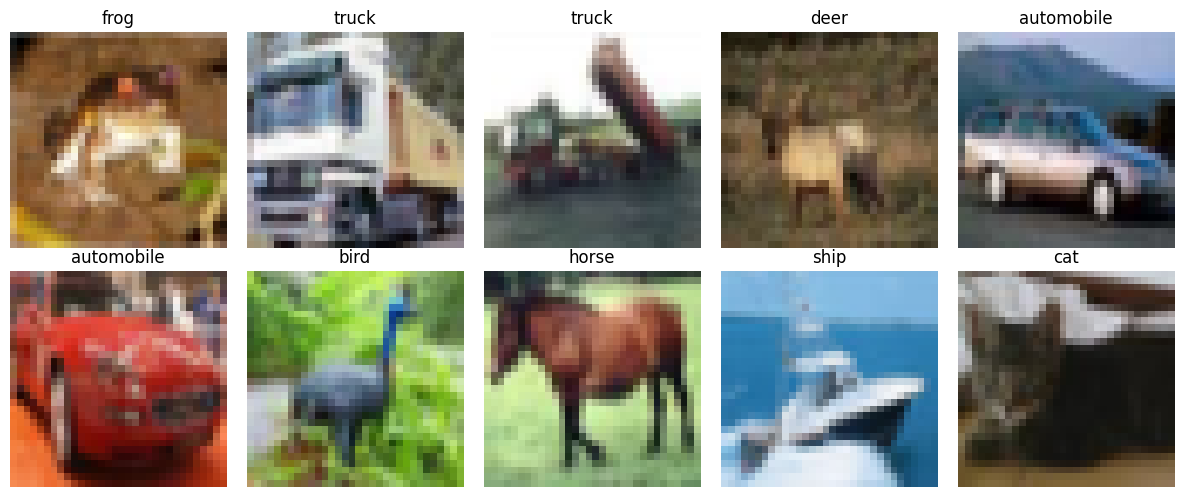

In [3]:
plt.figure(figsize=(12,5))
for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(x_train[i])
    plt.title(class_names[y_train[i][0]])
    plt.axis("off")
plt.tight_layout()
plt.show()


## Preprocessing

In [4]:
x_train_norm = x_train.astype("float32") / 255.0
x_test_norm = x_test.astype("float32") / 255.0

x_train_flat = x_train_norm.reshape(len(x_train_norm), -1)
x_test_flat = x_test_norm.reshape(len(x_test_norm), -1)


## ANN Model

In [5]:
ann_model = models.Sequential([
    layers.Input(shape=(3072,)),
    layers.Dense(512, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(256, activation='relu'),
    layers.Dense(10, activation='softmax')
])

ann_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

ann_history = ann_model.fit(
    x_train_flat,
    y_train,
    validation_split=0.1,
    epochs=10,
    batch_size=64,
    verbose=1
)

ann_loss, ann_acc = ann_model.evaluate(x_test_flat, y_test)
print("ANN Test Accuracy:", ann_acc)


Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 8s 7ms/step - accuracy: 0.2665 - loss: 2.0004 - val_accuracy: 0.3346 - val_loss: 1.8335
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.3092 - loss: 1.8767 - val_accuracy: 0.3408 - val_loss: 1.8059
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.3244 - loss: 1.8409 - val_accuracy: 0.3502 - val_loss: 1.8050
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.3442 - loss: 1.7931 - val_accuracy: 0.3922 - val_loss: 1.7194
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.3524 - loss: 1.7740 - val_accuracy: 0.3982 - val_loss: 1.7259
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.3643 - loss: 1.7459 - val_accuracy: 0.3738 - val_loss: 1.7226
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.3705 - loss: 1.7309 - val_accuracy: 0.4142 - val_loss: 1.6829
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.3774 - loss: 1.7133 - val_accuracy: 0.

## CNN Model

In [6]:
cnn_model = models.Sequential([
    layers.Input(shape=(32,32,3)),
    layers.Conv2D(32, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])

cnn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

cnn_history = cnn_model.fit(
    x_train_norm,
    y_train,
    validation_split=0.1,
    epochs=10,
    batch_size=64,
    verbose=1
)

cnn_loss, cnn_acc = cnn_model.evaluate(x_test_norm, y_test)
print("CNN Test Accuracy:", cnn_acc)


Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 14s 11ms/step - accuracy: 0.4652 - loss: 1.4969 - val_accuracy: 0.5714 - val_loss: 1.2350
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.5993 - loss: 1.1405 - val_accuracy: 0.6270 - val_loss: 1.0632
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.6646 - loss: 0.9611 - val_accuracy: 0.5866 - val_loss: 1.1683
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.7083 - loss: 0.8410 - val_accuracy: 0.6568 - val_loss: 1.0460
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.7387 - loss: 0.7481 - val_accuracy: 0.6778 - val_loss: 0.9434
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.7670 - loss: 0.6697 - val_accuracy: 0.6434 - val_loss: 1.1267
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.7907 - loss: 0.5965 - val_accuracy: 0.6826 - val_loss: 0.9539
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.8101 - loss: 0.5377 - val_accuracy: 

## Improved CNN with Augmentation + EarlyStopping

In [7]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1)
])

early_stop = callbacks.EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

improved_cnn = models.Sequential([
    data_augmentation,

    layers.Conv2D(32,3,padding='same',activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),

    layers.Conv2D(64,3,padding='same',activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),

    layers.Conv2D(128,3,padding='same',activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),

    layers.Flatten(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(10, activation='softmax')
])

improved_cnn.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

improved_history = improved_cnn.fit(
    x_train_norm,
    y_train,
    validation_split=0.1,
    epochs=20,
    batch_size=64,
    callbacks=[early_stop],
    verbose=1
)

improved_loss, improved_acc = improved_cnn.evaluate(x_test_norm, y_test)
print("Improved CNN Accuracy:", improved_acc)


Epoch 1/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 19s 15ms/step - accuracy: 0.3788 - loss: 1.7400 - val_accuracy: 0.5054 - val_loss: 1.4002
Epoch 2/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 15s 13ms/step - accuracy: 0.4842 - loss: 1.4409 - val_accuracy: 0.5500 - val_loss: 1.2915
Epoch 3/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 9s 13ms/step - accuracy: 0.5366 - loss: 1.3113 - val_accuracy: 0.5732 - val_loss: 1.2843
Epoch 4/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step - accuracy: 0.5650 - loss: 1.2320 - val_accuracy: 0.5784 - val_loss: 1.1856
Epoch 5/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 9s 13ms/step - accuracy: 0.5973 - loss: 1.1492 - val_accuracy: 0.6644 - val_loss: 0.9679
Epoch 6/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 9s 13ms/step - accuracy: 0.6154 - loss: 1.1033 - val_accuracy: 0.6752 - val_loss: 0.9389
Epoch 7/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 9s 13ms/step - accuracy: 0.6296 - loss: 1.0639 - val_accuracy: 0.6636 - val_loss: 0.9781
Epoch 8/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 8s 12ms/step - accuracy: 0.6463 - loss: 1.0266 - val_ac

## Accuracy Comparison

In [8]:
comparison = pd.DataFrame({
    'Model':['ANN','CNN','Improved CNN'],
    'Accuracy':[ann_acc, cnn_acc, improved_acc]
})

comparison.sort_values('Accuracy', ascending=False)


,Model,Accuracy
2,Improved CNN,0.7119
1,CNN,0.6876
0,ANN,0.4249


## Model Architecture Summary

In [9]:
print('ANN Architecture')
ann_model.summary()

print('\nCNN Architecture')
cnn_model.summary()

print('\nImproved CNN Architecture')
improved_cnn.summary()


ANN Architecture


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 512)            │     1,573,376 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,121,824 (19.54 MB)

 Trainable params: 1,707,274 (6.51 MB)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_2 (Sequential)       │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,862,880 (7.11 MB)

 Trainable params: 620,810 (2.37 MB)

 Non-trainable params: 448 (1.75 KB)

 Optimizer params: 1,241,622 (4.74 MB)

## Performance Analysis

In [10]:
print(f'ANN Accuracy: {ann_acc:.4f}')
print(f'CNN Accuracy: {cnn_acc:.4f}')
print(f'Improved CNN Accuracy: {improved_acc:.4f}')
ann_to_cnn=((cnn_acc-ann_acc)/ann_acc)*100
cnn_to_improved=((improved_acc-cnn_acc)/cnn_acc)*100
print(f'CNN improved over ANN by {ann_to_cnn:.2f}%')
print(f'Improved CNN improved over CNN by {cnn_to_improved:.2f}%')


ANN Accuracy: 0.4249
CNN Accuracy: 0.6876
Improved CNN Accuracy: 0.7119
CNN improved over ANN by 61.83%
Improved CNN improved over CNN by 3.53%


## Accuracy Bar Chart

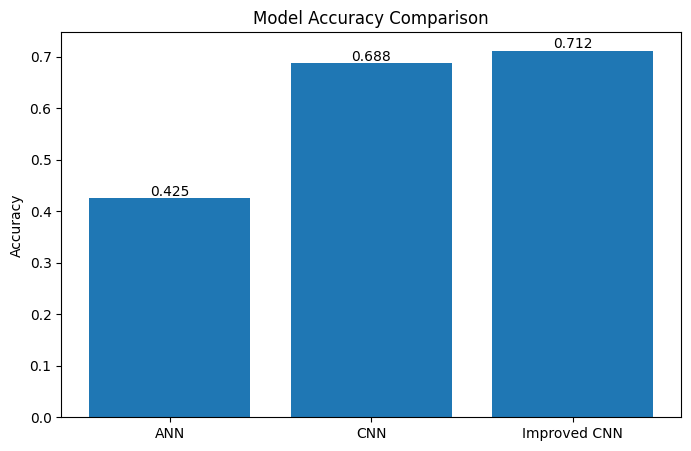

In [11]:
plt.figure(figsize=(8,5))
plt.bar(comparison['Model'], comparison['Accuracy'])
plt.title('Model Accuracy Comparison')
plt.ylabel('Accuracy')
for i,v in enumerate(comparison['Accuracy']):
    plt.text(i,v+0.005,f'{v:.3f}',ha='center')
plt.show()


## Validation Accuracy Curves

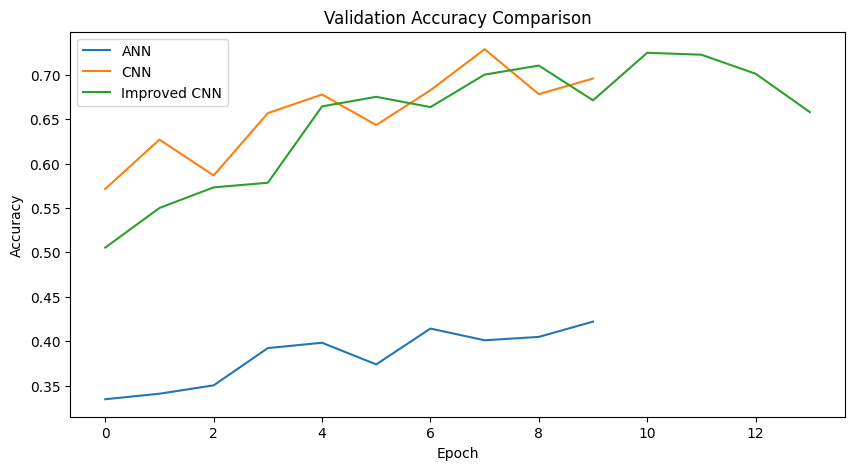

In [12]:
plt.figure(figsize=(10,5))

plt.plot(ann_history.history['val_accuracy'], label='ANN')
plt.plot(cnn_history.history['val_accuracy'], label='CNN')
plt.plot(improved_history.history['val_accuracy'], label='Improved CNN')

plt.title('Validation Accuracy Comparison')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()


## Validation Loss Curves

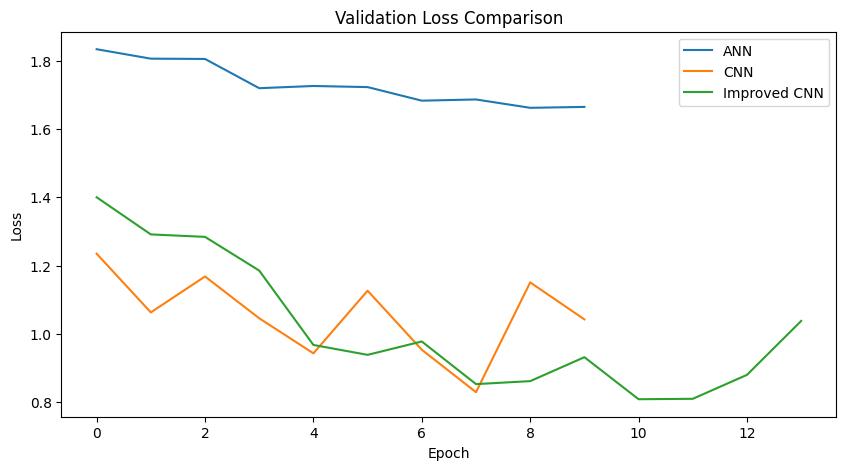

In [13]:
plt.figure(figsize=(10,5))

plt.plot(ann_history.history['val_loss'], label='ANN')
plt.plot(cnn_history.history['val_loss'], label='CNN')
plt.plot(improved_history.history['val_loss'], label='Improved CNN')

plt.title('Validation Loss Comparison')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()


## Confusion Matrix

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


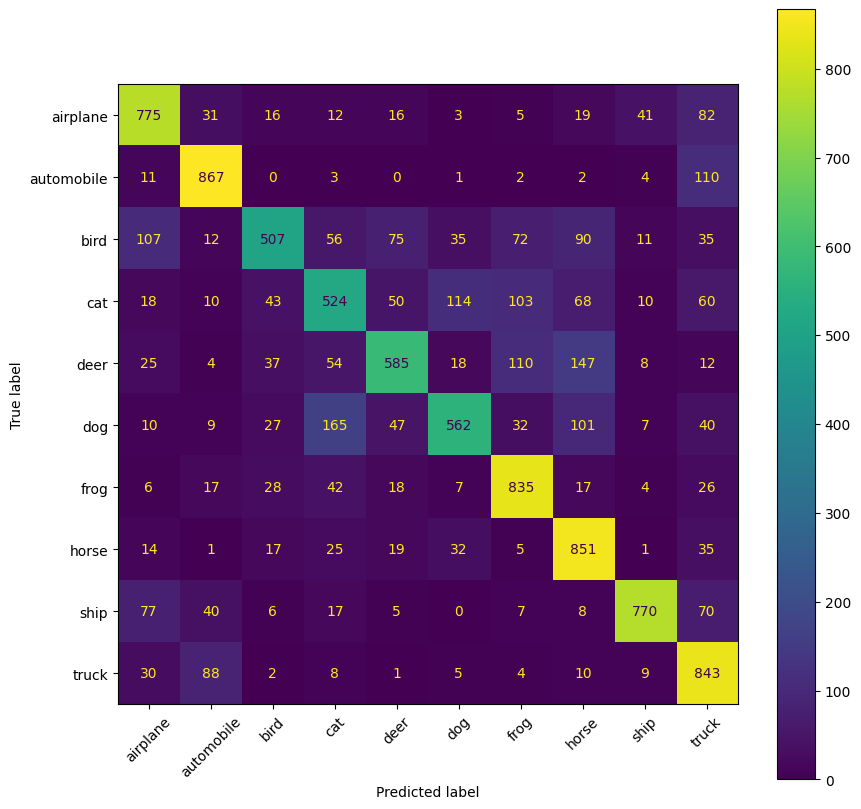

In [14]:
predictions = improved_cnn.predict(x_test_norm)
y_pred = np.argmax(predictions, axis=1)

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

fig, ax = plt.subplots(figsize=(10,10))
disp.plot(ax=ax, xticks_rotation=45)
plt.show()


## Classification Report

In [15]:
print(classification_report(
    y_test,
    y_pred,
    target_names=class_names
))


              precision    recall  f1-score   support

    airplane       0.72      0.78      0.75      1000
  automobile       0.80      0.87      0.83      1000
        bird       0.74      0.51      0.60      1000
         cat       0.58      0.52      0.55      1000
        deer       0.72      0.58      0.64      1000
         dog       0.72      0.56      0.63      1000
        frog       0.71      0.83      0.77      1000
       horse       0.65      0.85      0.74      1000
        ship       0.89      0.77      0.83      1000
       truck       0.64      0.84      0.73      1000

    accuracy                           0.71     10000
   macro avg       0.72      0.71      0.71     10000
weighted avg       0.72      0.71      0.71     10000



## Conclusion

In [16]:
print('ANN performs worst because images are flattened.')
print('CNN captures spatial features and performs significantly better.')
print('Batch Normalization, Dropout, Data Augmentation and EarlyStopping improve generalization.')
print('Improved CNN achieves the best overall performance on CIFAR-10.')


ANN performs worst because images are flattened.
CNN captures spatial features and performs significantly better.
Batch Normalization, Dropout, Data Augmentation and EarlyStopping improve generalization.
Improved CNN achieves the best overall performance on CIFAR-10.
